In [1]:
%cd /kaggle/working
!git clone https://github.com/AmirEspahbodi/bac.git

/kaggle/working
fatal: destination path 'bac' already exists and is not an empty directory.


In [ ]:
!pip install bitsandbytes

In [2]:
%cd /kaggle/working/bac
!git pull
!ls

/kaggle/working/bac
Already up to date.
datasets     poetry.lock     README.md	src
inspiration  pyproject.toml  scripts	state.db


In [3]:
import os
import json
import matplotlib.pyplot as plt


def plot_history(result_load_path, NUM_EPOCHS):
    loss_train_hist = None
    loss_valid_hist = None
    acc_train_hist = None
    acc_valid_hist = None
    test_top_5_acc = None
    test_top_10_acc = None
    test_loss_final = None
    test_acc_top1_final = None
    test_mrr_final = None
        
    # Load the data from the JSON file
    try:
        with open(result_load_path, "r") as f:
            # json.load() reads the file and parses the JSON data into a Python dictionary
            loaded_results = json.load(f)
    
        # Unpack the dictionary values into your variables
        loss_train_hist = loaded_results.get("loss_train_hist")
        loss_valid_hist = loaded_results.get("loss_valid_hist")
        acc_train_hist = loaded_results.get("acc_train_hist")
        acc_valid_hist = loaded_results.get("acc_valid_hist")
        test_top_5_acc = loaded_results.get("test_top_5_acc")
        test_top_10_acc = loaded_results.get("test_top_10_acc")
        test_loss_final = loaded_results.get("test_loss_final")
        test_acc_top1_final = loaded_results.get("test_acc_top1_final")
        test_mrr_final = loaded_results.get("test_mrr_final")
    
    except FileNotFoundError:
        print(f"Error: The file at '{result_load_path}' was not found.")
    except json.JSONDecodeError:
        print(f"Error: The file at '{result_load_path}' is not a valid JSON file.")
    except Exception as e:
        print(f"An unexpected error occurred: {e}")
    
    epochs_range = range(1, NUM_EPOCHS + 1)
    
    plt.figure(figsize=(14, 6))
    
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, loss_train_hist, "bo-", label="Training Loss")
    plt.plot(epochs_range, loss_valid_hist, "ro-", label="Validation Loss")
    plt.title("Training and Validation Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, acc_train_hist, "bo-", label="Training Accuracy (Top-1)")
    plt.plot(epochs_range, acc_valid_hist, "ro-", label="Validation Accuracy (Top-1)")
    plt.title("Training and Validation Accuracy (Top-1)")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True)
    
    plt.tight_layout()
    plt.show()

## GCC dataset

In [4]:
!python -m src.run_lstm -e bert -d gcc -ne 7 -rsw 0 -a 1 -b 1 -r 1 -hs 256 -l 2 -nah 1 -lam concat

2025-07-12 13:13:31.439059: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1752326011.627244      86 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1752326011.680074      86 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
Shape after dropping NA assignees: (2103, 6)
Number of unique assignees (classes): 82
✅ Loading pre-saved augmented dataset from 'datasets/augmented_train_dataset_2_GCC.csv'.
tokenizer_config.json: 100%|██████████████████| 48.0/48.0 [00:00<00:00, 239kB/s]
vocab.txt: 100%|█████████████████████████████| 232k/232k [00:00<00:00, 3.59MB/s]
tokenizer.json: 100%|████████████████████████| 466k/466k [00:00<00:00, 7.29MB/s]
config.json: 100%|█

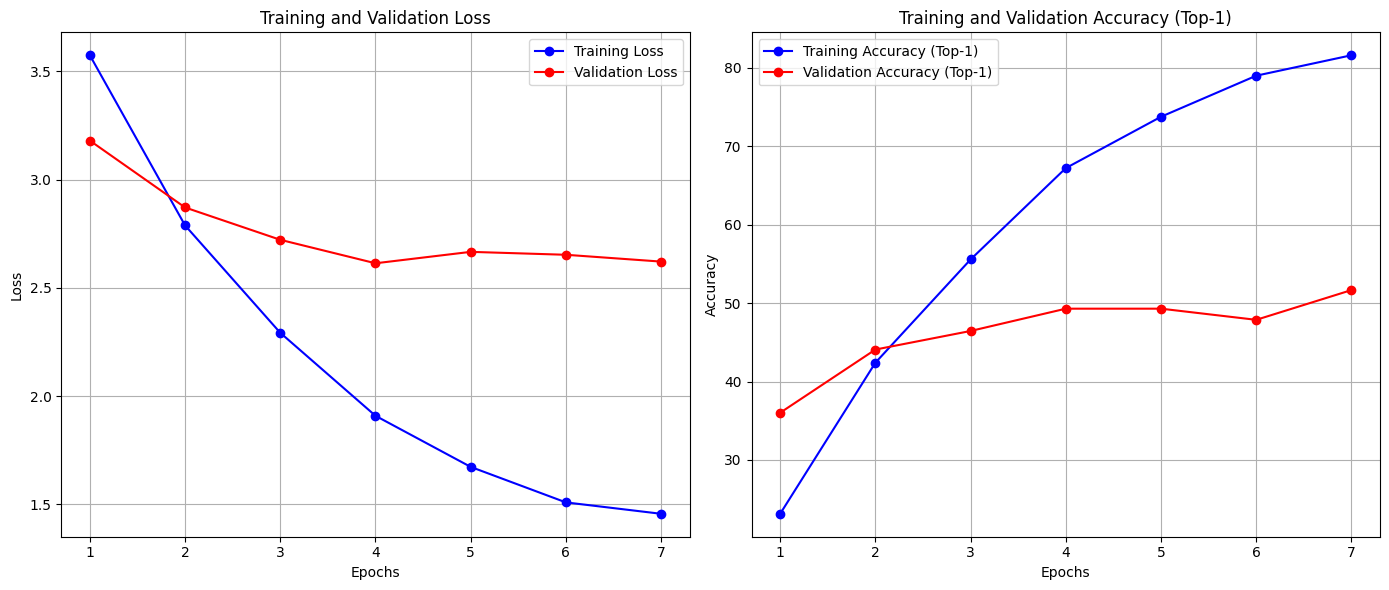

In [5]:
result_load_path = f"{os.getcwd()}/.result/lstm_bert_result.json"
plot_history(result_load_path, 7)

## JDT dataset

In [6]:
!python -m src.run_lstm -e bert -d jdt -ne 7 -rsw 0 -a 1 -b 1 -r 1 -hs 256 -l 2 -nah 1 -lam concat

2025-07-12 13:25:50.881181: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1752326750.904792     352 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1752326750.911992     352 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
Shape after dropping NA assignees: (1465, 5)
Number of unique assignees (classes): 69
✅ Loading pre-saved augmented dataset from 'datasets/augmented_train_dataset_2_JDT.csv'.
Using device: cuda
Generating Full Embeddings: 100%|███████████████| 19/19 [00:06<00:00,  3.15it/s]

DataLoaders created successfully!
Training batches: 193
Validation batches: 10
Test batches: 19
using bert embeddings

------
lstm model info: 
{'total_parameter

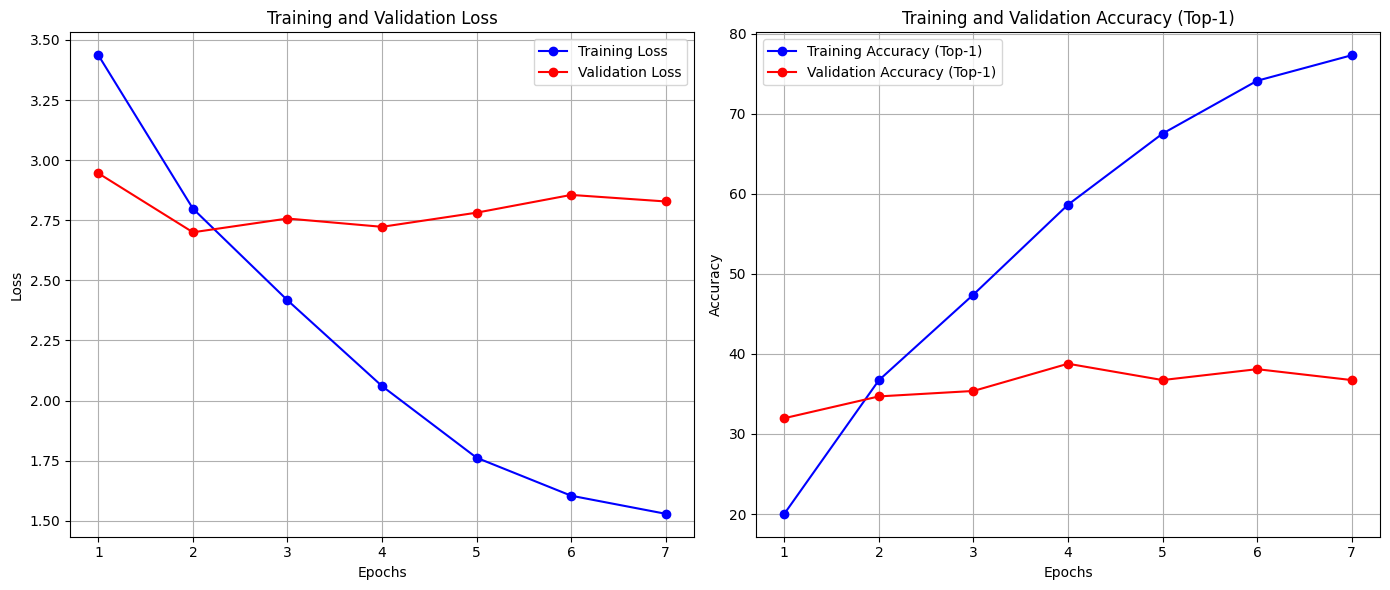

In [7]:
result_load_path = f"{os.getcwd()}/.result/lstm_bert_result.json"
plot_history(result_load_path, 7)